In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.utils import shuffle

In [2]:
df = pd.read_csv('income.csv')

In [3]:
print(len(df))
df.head()

30000


,age,sex,education,education-num,marital-status,workclass,occupation,hours-per-week,income,label
0,27,Male,HS-grad,9,Never-married,Private,Craft-repair,40,<=50K,0
1,47,Male,Masters,14,Married,Local-gov,Exec-managerial,50,>50K,1
2,59,Male,HS-grad,9,Divorced,Self-emp,Prof-specialty,20,<=50K,0
3,38,Female,Prof-school,15,Never-married,Federal-gov,Prof-specialty,57,>50K,1
4,64,Female,11th,7,Widowed,Private,Farming-fishing,40,<=50K,0


In [4]:
df['label'].value_counts()

label
0    21700
1     8300
Name: count, dtype: int64

In [5]:
df.columns

Index(['age', 'sex', 'education', 'education-num', 'marital-status',
       'workclass', 'occupation', 'hours-per-week', 'income', 'label'],
      dtype='object')

In [6]:
cat_cols = ['sex', 'education', 'marital-status', 'workclass', 'occupation']
cont_cols = ['age','hours-per-week']
y_col = ['label']
print(f'cat_cols has {len(cat_cols)} columns')
print(f'cont_cols has {len(cont_cols)} columns')
print(f'y_col has {len(y_col)} columns')

cat_cols has 5 columns
cont_cols has 2 columns
y_col has 1 columns


In [7]:
df = shuffle(df,random_state = 101)
df.reset_index(drop=True,inplace = True)
df.head()

,age,sex,education,education-num,marital-status,workclass,occupation,hours-per-week,income,label
0,23,Female,HS-grad,9,Never-married,Private,Other-service,50,<=50K,0
1,37,Female,Prof-school,15,Married,State-gov,Prof-specialty,39,>50K,1
2,34,Male,Some-college,10,Divorced,Private,Adm-clerical,40,<=50K,0
3,31,Male,HS-grad,9,Married,Private,Craft-repair,40,>50K,1
4,20,Female,Some-college,10,Never-married,Private,Sales,25,<=50K,0


In [8]:
for col in cat_cols:
    df[col] = df[col].astype('category')

In [9]:
# 3. Set the embedding sizes

cat_szs = [len(df[col].cat.categories) for col in cat_cols]

emb_szs = [(size, min(50, (size + 1) // 2)) for size in cat_szs]

print(emb_szs)

[(2, 1), (14, 7), (6, 3), (5, 3), (12, 6)]


In [10]:
cats = np.stack([df[col].cat.codes.values for col in cat_cols], 1)

cats[:5]

array([[ 0, 10,  3,  2,  6],
       [ 0, 12,  1,  4,  7],
       [ 1, 13,  0,  2,  0],
       [ 1, 10,  1,  2,  1],
       [ 0, 13,  3,  2,  9]], dtype=int8)

In [11]:
# 5. Convert "cats" to a tensor

cats = torch.tensor(cats, dtype=torch.int64)

In [12]:
# 6. Create an array of continuous values

conts = np.stack([df[col].values for col in cont_cols], 1)

conts[:5]

array([[23, 50],
       [37, 39],
       [34, 40],
       [31, 40],
       [20, 25]])

In [13]:
# 7. Convert "conts" to a tensor

conts = torch.tensor(conts, dtype=torch.float32)

conts.dtype

torch.float32

In [14]:
# 8. Create a label tensor

y = torch.tensor(df[y_col].values.flatten(), dtype=torch.int64)

In [15]:
# 9. Create train and test sets

b = 30000
t = 5000

cat_train = cats[:b-t]
cat_test = cats[b-t:b]

con_train = conts[:b-t]
con_test = conts[b-t:b]

y_train = y[:b-t]
y_test = y[b-t:b]

In [16]:
# 10. Set the random seed

torch.manual_seed(33)

In [18]:
class TabularModel(nn.Module):

    def __init__(self, emb_szs, n_cont, out_sz, layers, p=0.5):
        
        super().__init__()

        self.embeds = nn.ModuleList(
            [nn.Embedding(ni, nf) for ni, nf in emb_szs]
        )

        self.emb_drop = nn.Dropout(p)

        self.bn_cont = nn.BatchNorm1d(n_cont)

        layerlist = []

        n_emb = sum((nf for ni, nf in emb_szs))
        n_in = n_emb + n_cont

        for i in layers:
            layerlist.append(nn.Linear(n_in, i))
            layerlist.append(nn.ReLU(inplace=True))
            layerlist.append(nn.BatchNorm1d(i))
            layerlist.append(nn.Dropout(p))
            n_in = i

        layerlist.append(nn.Linear(layers[-1], out_sz))

        self.layers = nn.Sequential(*layerlist)

    def forward(self, x_cat, x_cont):

        embeddings = []

        for i, e in enumerate(self.embeds):
            embeddings.append(e(x_cat[:, i]))

        x = torch.cat(embeddings, 1)

        x = self.emb_drop(x)

        x_cont = self.bn_cont(x_cont)

        x = torch.cat([x, x_cont], 1)

        x = self.layers(x)

        return x

In [19]:
# 11. Create a TabularModel instance

model = TabularModel(
    emb_szs,
    n_cont=len(cont_cols),
    out_sz=2,
    layers=[50],
    p=0.4
)

model

TabularModel(
  (embeds): ModuleList(
    (0): Embedding(2, 1)
    (1): Embedding(14, 7)
    (2): Embedding(6, 3)
    (3): Embedding(5, 3)
    (4): Embedding(12, 6)
  )
  (emb_drop): Dropout(p=0.4, inplace=False)
  (bn_cont): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): Sequential(
    (0): Linear(in_features=22, out_features=50, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=50, out_features=2, bias=True)
  )
)

In [20]:
# 12. Define the loss and optimization functions

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [22]:
import time
start_time = time.time()

epochs = 300
losses = []

for i in range(epochs):
    i += 1
    
    y_pred = model(cat_train, con_train)
    
    loss = criterion(y_pred, y_train)
    
    losses.append(loss.item())

    if i % 25 == 1:
        print(f'epoch: {i:3}  loss: {loss.item():10.8f}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f'epoch: {i:3}  loss: {loss.item():10.8f}')

print(f'\nDuration: {time.time() - start_time:.0f} seconds')

epoch:   1  loss: 0.81377232
epoch:  26  loss: 0.59307522
epoch:  51  loss: 0.51390457
epoch:  76  loss: 0.46117699
epoch: 101  loss: 0.42819440
epoch: 126  loss: 0.39755958
epoch: 151  loss: 0.38082534
epoch: 176  loss: 0.35858384
epoch: 201  loss: 0.34402204
epoch: 226  loss: 0.33575210
epoch: 251  loss: 0.32717407
epoch: 276  loss: 0.32316059
epoch: 300  loss: 0.31616521

Duration: 24 seconds


Text(0.5, 0, 'epoch')

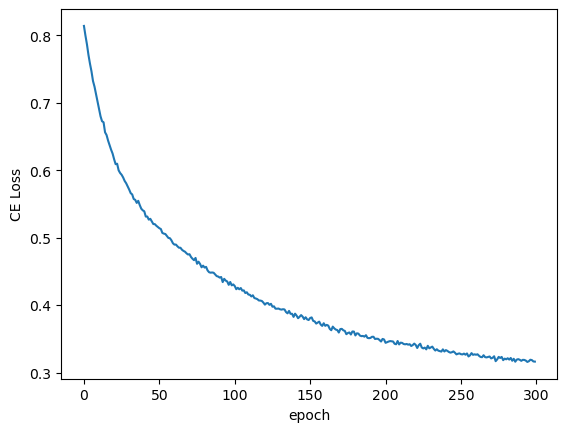

In [23]:
# 13. Plot the Cross Entropy Loss against epochs

plt.plot(range(epochs), losses)
plt.ylabel('CE Loss')
plt.xlabel('epoch')

In [24]:
# 14. Evaluate the test set

with torch.no_grad():
    y_val = model(cat_test, con_test)
    loss = criterion(y_val, y_test)

print(f'CE Loss: {loss:.8f}')

CE Loss: 0.33355838


In [25]:
# 15. Calculate the overall percent accuracy

correct = 0

with torch.no_grad():
    for i in range(len(y_test)):
        if y_val[i].argmax().item() == y_test[i]:
            correct += 1

print(f'{correct} out of {len(y_test)} = {100*correct/len(y_test):7.2f}% correct')

4222 out of 5000 =   84.44% correct


In [28]:
model.eval()

def predict_income():

    age = int(input("What is the person's age? (18-90) "))

    sex = input("What is the person's sex? (Male/Female) ").title()
    sex_d = {'Female':0, 'Male':1}

    education = input("What is the person's education level? ")
    edu_d = {k:v for v,k in enumerate(df['education'].cat.categories)}

    marital = input("What is the person's marital status? ")
    mar_d = {k:v for v,k in enumerate(df['marital-status'].cat.categories)}

    workclass = input("What is the person's workclass? ")
    work_d = {k:v for v,k in enumerate(df['workclass'].cat.categories)}

    occupation = input("What is the person's occupation? ")
    occ_d = {k:v for v,k in enumerate(df['occupation'].cat.categories)}

    hours = int(input("How many hours/week are worked? (20-90) "))

    cats = torch.tensor([
        sex_d[sex],
        edu_d[education],
        mar_d[marital],
        work_d[workclass],
        occ_d[occupation]
    ], dtype=torch.int64).reshape(1,-1)

    conts = torch.tensor([age, hours], dtype=torch.float32).reshape(1,-1)

    with torch.no_grad():
        prediction = model(cats, conts).argmax().item()

    print(f'\nThe predicted label is {prediction}')

predict_income()

What is the person's age? (18-90)  22
What is the person's sex? (Male/Female)  Male
What is the person's education level?  HS-grad
What is the person's marital status?  Never-married
What is the person's workclass?  Private
What is the person's occupation?  Sales
How many hours/week are worked? (20-90)  40



The predicted label is 0
